In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Veriyi okuma (Bir üst klasöre çıkıp data/raw içine giriyoruz)
df = pd.read_csv('../data/raw/churn_data.csv')

# İlk 5 satıra göz atalım
display(df.head())

# Veri setinin yapısal özeti (Hangi sütunda kaç dolu veri var, tipleri neler?)
df.info()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [2]:
from ydata_profiling import ProfileReport

# Veri seti için interaktif bir HTML raporu oluştur
profil = ProfileReport(df, title="Telco Churn Veri Profili")

# Raporu notebooks klasörüne HTML olarak kaydet
profil.to_file("01_churn_raporu.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:00<00:00, 399.03it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [3]:
# 1. TotalCharges sütununu zorla sayısal (float) tipe çeviriyoruz. 
# errors='coerce' komutu, sayıya çevrilemeyen o boşluk karakterlerini NaN (boş veri) yapar.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Şimdi o NaN olan değerleri 0 ile dolduralım (çünkü henüz hiç ödeme yapmadılar)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 2. Modele hiçbir faydası olmayan Müşteri ID sütununu siliyoruz
df.drop('customerID', axis=1, inplace=True)

# 3. Makine öğrenmesi modeli "Yes" veya "No" kelimelerinden anlamaz. 
# Hedef değişkenimiz olan Churn'ü 1 (Terk Etti) ve 0 (Kaldı) olarak sayısallaştırıyoruz.
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Temizlik sonrası verinin yeni durumuna bakalım
display(df.head())
df.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Hedef değişken (y) ve özellikler (X) olarak ayırma
X = df.drop('Churn', axis=1)
y = df['Churn']

# Sütun tiplerini otomatik olarak ayırma
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 1. Sayısal veriler için işlem adımı: Ölçeklendirme (0-1 arası standartlaştırma)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# 2. Kategorik (metin) veriler için işlem adımı: One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. İki işlemi tek bir ön işleme (Preprocessor) motorunda birleştirme
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Veriyi %80 Eğitim (Train) ve %20 Test olarak bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline'ı eğitim verisiyle eğitme ve dönüştürme (Fit & Transform)
X_train_processed = preprocessor.fit_transform(X_train)

# Test verisini sadece dönüştürme (Transform - Veri sızıntısını önlemek için fit yapılmaz)
X_test_processed = preprocessor.transform(X_test)

print("İşlem Başarılı! Pipeline veri setini makine öğrenmesine hazır hale getirdi.")
print(f"Eğitim verisi satır/sütun boyutu: {X_train_processed.shape}")
print(f"Test verisi satır/sütun boyutu: {X_test_processed.shape}")

İşlem Başarılı! Pipeline veri setini makine öğrenmesine hazır hale getirdi.
Eğitim verisi satır/sütun boyutu: (5634, 44)
Test verisi satır/sütun boyutu: (1409, 44)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
import numpy as np

# Modelleri varsayılan (baseline) ayarlarıyla tanımlama
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(random_state=42)

# Takip edeceğimiz çoklu metrikler
scoring = ['accuracy', 'precision', 'recall', 'f1']

print("Model Eğitimleri Başladı (5-Fold Cross Validation). Lütfen bekleyin...\n")

# Lojistik Regresyon için Cross-Validation
print("--- LOJİSTİK REGRESYON SKORLARI ---")
log_cv = cross_validate(log_reg, X_train_processed, y_train, cv=5, scoring=scoring)
print(f"Accuracy:  {np.mean(log_cv['test_accuracy']):.4f}")
print(f"Precision: {np.mean(log_cv['test_precision']):.4f}")
print(f"Recall:    {np.mean(log_cv['test_recall']):.4f}")
print(f"F1-Score:  {np.mean(log_cv['test_f1']):.4f}\n")

# Random Forest için Cross-Validation
print("--- RANDOM FOREST SKORLARI ---")
rf_cv = cross_validate(rf_model, X_train_processed, y_train, cv=5, scoring=scoring)
print(f"Accuracy:  {np.mean(rf_cv['test_accuracy']):.4f}")
print(f"Precision: {np.mean(rf_cv['test_precision']):.4f}")
print(f"Recall:    {np.mean(rf_cv['test_recall']):.4f}")
print(f"F1-Score:  {np.mean(rf_cv['test_f1']):.4f}")

Model Eğitimleri Başladı (5-Fold Cross Validation). Lütfen bekleyin...

--- LOJİSTİK REGRESYON SKORLARI ---
Accuracy:  0.8005
Precision: 0.6529
Recall:    0.5348
F1-Score:  0.5872

--- RANDOM FOREST SKORLARI ---
Accuracy:  0.7824
Precision: 0.6179
Recall:    0.4726
F1-Score:  0.5352


In [6]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
import numpy as np

# 1. SMOTE Tanımlaması (Sadece eğitim sırasında çalışacak)
smote = SMOTE(random_state=42)

# 2. Önceden oluşturduğumuz ön işleme adımları
numeric_transformer = ImbPipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = ImbPipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 3. Modellerin Tanımlanması
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(random_state=42)

# 4. UÇTAN UCA YENİ PİPELİNE: Veri -> Ön İşleme -> SMOTE -> Model
pipeline_log = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', log_reg)
])

pipeline_rf = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', rf_model)
])

# 5. Modelleri Çapraz Doğrulama (Cross-Validation) ile Test Etme
scoring = ['accuracy', 'precision', 'recall', 'f1']

print("SMOTE Entegre Edilmiş Model Eğitimleri Başladı...\n")

# Lojistik Regresyon
print("--- SMOTE + LOJİSTİK REGRESYON ---")
log_cv = cross_validate(pipeline_log, X_train, y_train, cv=5, scoring=scoring)
print(f"Accuracy:  {np.mean(log_cv['test_accuracy']):.4f}")
print(f"Precision: {np.mean(log_cv['test_precision']):.4f}")
print(f"Recall:    {np.mean(log_cv['test_recall']):.4f}")
print(f"F1-Score:  {np.mean(log_cv['test_f1']):.4f}\n")

# Random Forest
print("--- SMOTE + RANDOM FOREST ---")
rf_cv = cross_validate(pipeline_rf, X_train, y_train, cv=5, scoring=scoring)
print(f"Accuracy:  {np.mean(rf_cv['test_accuracy']):.4f}")
print(f"Precision: {np.mean(rf_cv['test_precision']):.4f}")
print(f"Recall:    {np.mean(rf_cv['test_recall']):.4f}")
print(f"F1-Score:  {np.mean(rf_cv['test_f1']):.4f}")

SMOTE Entegre Edilmiş Model Eğitimleri Başladı...

--- SMOTE + LOJİSTİK REGRESYON ---
Accuracy:  0.7446
Precision: 0.5124
Recall:    0.7995
F1-Score:  0.6243

--- SMOTE + RANDOM FOREST ---
Accuracy:  0.7744
Precision: 0.5776
Recall:    0.5588
F1-Score:  0.5679


In [7]:
from sklearn.model_selection import GridSearchCV

# Random Forest için denenecek hiperparametre kombinasyonları
# Not: Pipeline kullandığımız için parametrelerin başına 'classifier__' ekliyoruz.
param_grid = {
    'classifier__n_estimators': [100, 200],           # Ormandaki ağaç sayısı
    'classifier__max_depth': [5, 10, None],           # Ağaçların maksimum derinliği (Ezberlemeyi önler)
    'classifier__min_samples_split': [5, 10],         # Bir düğümü bölmek için gereken minimum veri
    'classifier__min_samples_leaf': [2, 5],           # En uç yaprakta kalması gereken minimum veri
    'classifier__class_weight': ['balanced', None]    # Sınıf ağırlıklandırması
}

# Hedef metriğimiz Recall olacak, çünkü asıl amacımız terk edenleri (Churn=1) yakalamak
grid_search = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    scoring='recall',       # Ana odak noktamız Duyarlılık
    cv=3,                   # Süreyi makul tutmak için 3 parçalı doğrulama
    n_jobs=-1,              # Bilgisayarın tüm işlemci çekirdeklerini tam kapasite kullan
    verbose=2               # İşlem adımlarını ekrana yazdır
)

print("Grid Search başlatılıyor. Bu işlem birkaç dakika sürebilir, lütfen bekleyin...\n")
grid_search.fit(X_train, y_train)

print("\n--- EN İYİ RANDOM FOREST PARAMETRELERİ ---")
for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")

print(f"\nEn İyi Çapraz Doğrulama Recall Skoru: {grid_search.best_score_:.4f}")

Grid Search başlatılıyor. Bu işlem birkaç dakika sürebilir, lütfen bekleyin...

Fitting 3 folds for each of 48 candidates, totalling 144 fits

--- EN İYİ RANDOM FOREST PARAMETRELERİ ---
classifier__class_weight: None
classifier__max_depth: 5
classifier__min_samples_leaf: 5
classifier__min_samples_split: 5
classifier__n_estimators: 100

En İyi Çapraz Doğrulama Recall Skoru: 0.7574


In [8]:
import joblib
import os

# Kazanan modelimizi (SMOTE + Lojistik Regresyon) tüm eğitim verisiyle kalıcı olarak eğitiyoruz
print("Nihai model eğitiliyor...")
pipeline_log.fit(X_train, y_train)

# Modelleri kaydedeceğimiz klasörün var olduğundan emin olalım
os.makedirs('../models', exist_ok=True)

# Modeli .joblib formatında kaydediyoruz (Şirket standartlarında versiyon ismiyle)
model_path = '../models/churn_model_v1.0.joblib'
joblib.dump(pipeline_log, model_path)

print(f"✅ İşlem Başarılı! Şampiyon model başarıyla dışa aktarıldı: {model_path}")
print("Artık bu dosya API servisine bağlanmaya hazır.")

Nihai model eğitiliyor...
✅ İşlem Başarılı! Şampiyon model başarıyla dışa aktarıldı: ../models/churn_model_v1.0.joblib
Artık bu dosya API servisine bağlanmaya hazır.



MÜŞTERİYİ TERK ETMEYE (CHURN) İTEN EN RİSKLİ 5 FAKTÖR:


,Feature,Importance
2,TotalCharges,0.924778
35,Contract_Month-to-month,0.698956
15,InternetService_Fiber optic,0.680790
34,StreamingMovies_Yes,0.307513
42,PaymentMethod_Electronic check,0.286358


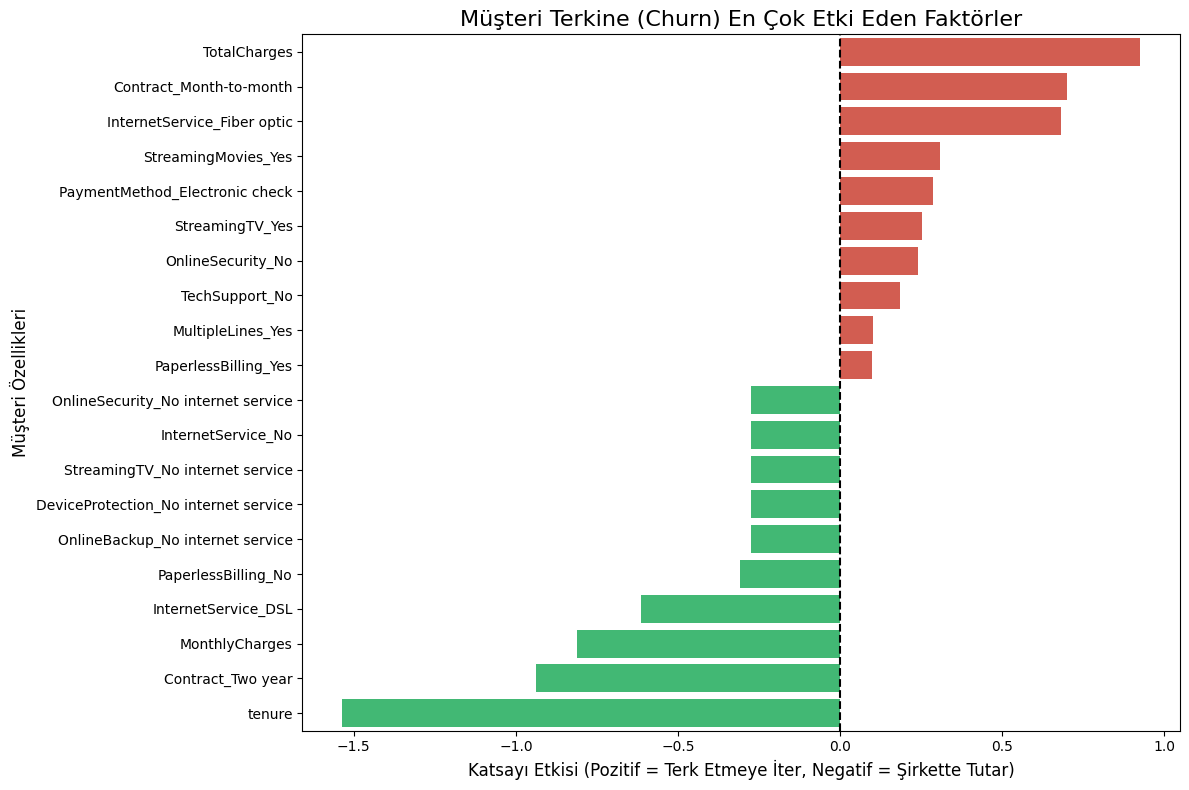

In [9]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pipeline içindeki eğitilmiş Lojistik Regresyon modelini ve ön işleme adımını çekelim
trained_model = pipeline_log.named_steps['classifier']
preprocessor = pipeline_log.named_steps['preprocessor']

# 2. OneHotEncoder sonrası oluşan yeni sütun isimlerini alalım
feature_names = preprocessor.get_feature_names_out()

# Sütun isimlerindeki gereksiz 'num__' ve 'cat__' eklerini temizleyelim
clean_feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

# 3. Modelin her bir özelliğe verdiği ağırlığı (katsayıyı) alalım
coefficients = trained_model.coef_[0]

# 4. Özellikleri ve katsayıları bir DataFrame'de birleştirelim
feature_importance = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': coefficients
})

# Katsayıları büyükten küçüğe sıralayalım
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# 5. En çok etki eden (Pozitif ve Negatif) ilk 10 özelliği görselleştirelim
top_features = pd.concat([feature_importance.head(10), feature_importance.tail(10)])

# Görsel boyutunu ve stilini ayarlayalım
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=top_features, 
            palette=["#e74c3c" if x > 0 else "#2ecc71" for x in top_features['Importance']])

plt.title('Müşteri Terkine (Churn) En Çok Etki Eden Faktörler', fontsize=16)
plt.xlabel('Katsayı Etkisi (Pozitif = Terk Etmeye İter, Negatif = Şirkette Tutar)', fontsize=12)
plt.ylabel('Müşteri Özellikleri', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()


# İlk 5 risk faktörünü yazdıralım
print("\nMÜŞTERİYİ TERK ETMEYE (CHURN) İTEN EN RİSKLİ 5 FAKTÖR:")
display(feature_importance.head(5))

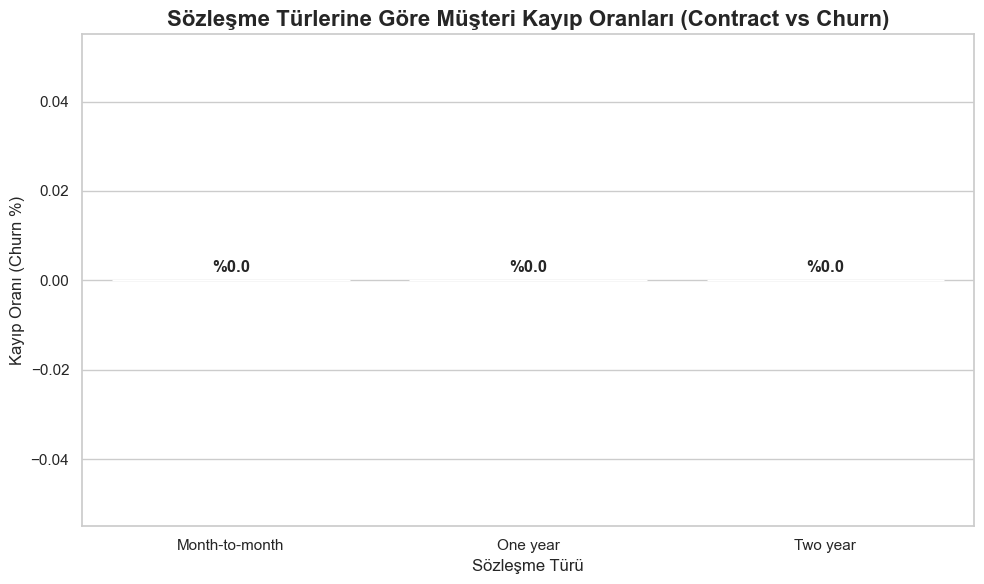

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# 1. Sözleşme türlerine göre Churn oranlarını (yüzdesel olarak) hesaplayalım
# Churn sütunundaki 'Yes' değerlerini 1, 'No' değerlerini 0 sayarak ortalama alıyoruz
churn_rates = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()

# 2. Grafik alanını ve stilini ayarlayalım
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Bar grafiğini çizelim (Renk paletini kırmızının tonları yaptık çünkü Churn = Risk)
ax = sns.barplot(x='Contract', y='Churn', data=churn_rates, palette='Reds_r')

# 4. Grafiğe başlık ve eksen isimleri ekleyelim
plt.title('Sözleşme Türlerine Göre Müşteri Kayıp Oranları (Contract vs Churn)', fontsize=16, fontweight='bold')
plt.xlabel('Sözleşme Türü', fontsize=12)
plt.ylabel('Kayıp Oranı (Churn %)', fontsize=12)

# 5. Barların üzerine yüzdelik değerleri yazdıralım
for p in ax.patches:
    ax.annotate(f'%{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

# Grafiği gösterelim
plt.tight_layout()
plt.show()

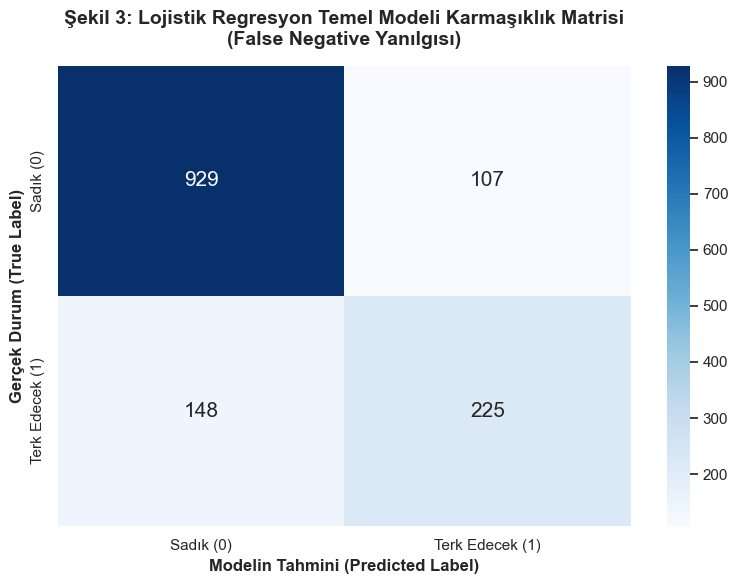

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# 1. SMOTE'suz Temel (Baseline) Lojistik Regresyon Pipeline'ını geçici olarak kuruyoruz
# Sadece sorunu kanıtlamak için kullanacağız
baseline_pipeline_log = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 2. Modeli eğitim verisiyle eğitip, kilitli kasadaki test verisiyle (X_test) tahmin yaptırıyoruz
baseline_pipeline_log.fit(X_train, y_train)
y_pred_baseline = baseline_pipeline_log.predict(X_test)

# 3. Karmaşıklık Matrisini (Confusion Matrix) hesaplıyoruz
cm = confusion_matrix(y_test, y_pred_baseline)

# 4. Seaborn Isı Haritası (Heatmap) ile çok daha şık bir görselleştirme
plt.figure(figsize=(8, 6))

# fmt='d' parametresi ile sayıların ondalıklı değil tam sayı görünmesini sağlıyoruz
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sadık (0)', 'Terk Edecek (1)'], 
            yticklabels=['Sadık (0)', 'Terk Edecek (1)'],
            annot_kws={"size": 15})

# İstediğin o özel başlığı tam olarak ekliyoruz
plt.title('Şekil 3: Lojistik Regresyon Temel Modeli Karmaşıklık Matrisi\n(False Negative Yanılgısı)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Modelin Tahmini (Predicted Label)', fontsize=12, fontweight='bold')
plt.ylabel('Gerçek Durum (True Label)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

--- MODEL EZBERLEME (OVERFITTING) KONTROLÜ ---
Eğitim (Train) Accuracy Skoru : %74.7
Test Accuracy Skoru           : %75.0
---------------------------------------------
Eğitim (Train) Recall Skoru   : %80.5
Test Recall Skoru             : %82.8
---------------------------------------------
Doğruluk Farkı (Gap)          : %0.3
SONUÇ: Harika! Modelde ezberleme (overfitting) yok, gerçek bir öğrenme gerçekleşmiş.


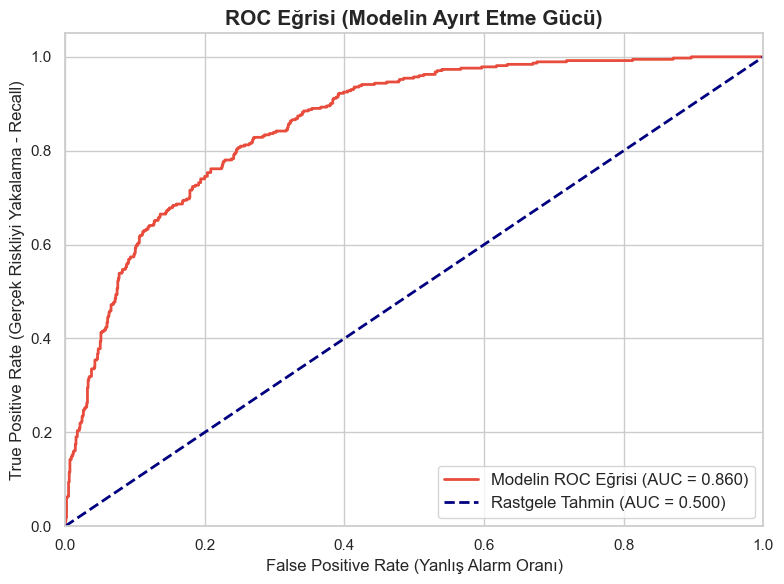

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, roc_curve, auc

# 1. Eğitim (Train) ve Test setleri için tahminleri alalım
# Modelin 'pipeline_log' adında olduğunu varsayıyoruz (son geliştirdiğimiz model)
y_train_pred = pipeline_log.predict(X_train)
y_test_pred = pipeline_log.predict(X_test)

# 2. Eğitim ve Test verisindeki "Olasılık" (Probability) değerlerini alalım (ROC için gerekli)
y_test_probs = pipeline_log.predict_proba(X_test)[:, 1]

# 3. Accuracy (Genel Doğruluk) ve Recall (Riskliyi Yakalama) Skorlarını Hesaplayalım
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)

print("--- MODEL EZBERLEME (OVERFITTING) KONTROLÜ ---")
print(f"Eğitim (Train) Accuracy Skoru : %{train_accuracy*100:.1f}")
print(f"Test Accuracy Skoru           : %{test_accuracy*100:.1f}")
print("-" * 45)
print(f"Eğitim (Train) Recall Skoru   : %{train_recall*100:.1f}")
print(f"Test Recall Skoru             : %{test_recall*100:.1f}")
print("-" * 45)

# 4. Aradaki Farkı (Gap) Yorumlayalım
acc_gap = abs(train_accuracy - test_accuracy) * 100
print(f"Doğruluk Farkı (Gap)          : %{acc_gap:.1f}")
if acc_gap < 5:
    print("SONUÇ: Harika! Modelde ezberleme (overfitting) yok, gerçek bir öğrenme gerçekleşmiş.")
else:
    print("SONUÇ: Uyarı! Eğitim ve Test arasında yüksek fark var, model veriyi ezberlemiş olabilir.")

# 5. ROC-AUC Eğrisi Çizimi
fpr, tpr, thresholds = roc_curve(y_test, y_test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# ROC eğrisini çizdiriyoruz
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'Modelin ROC Eğrisi (AUC = {roc_auc:.3f})')
# Rastgele tahmin (kötü model) referans çizgisini çizdiriyoruz
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Rastgele Tahmin (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Alarm Oranı)', fontsize=12)
plt.ylabel('True Positive Rate (Gerçek Riskliyi Yakalama - Recall)', fontsize=12)
plt.title('ROC Eğrisi (Modelin Ayırt Etme Gücü)', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()